In [1]:
# deriving pauli matrix z or sigma_3 with having expected value 1 and -1 and normal states
# ex 2.1
from qutip import *
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
import numpy as np
import math
from qutip import (Qobj, about, basis, coherent, coherent_dm, create, destroy,
                   expect, fock, fock_dm, mesolve, qeye, tensor, thermal_dm, anim_matrix_histogram,
                   anim_fock_distribution)
A = Qobj([[1], [0]])
B = np.array([[1,0]])
B1 = Qobj(B)
C = Qobj([[0], [1]])
D = np.array([[0,1]])
D1 = Qobj(D)
sigma_z = (1*A*B1)+(-1*C*D1)
print("Here is pauli matrix z :")
sigma_z

Here is pauli matrix z :


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]

In [2]:
# deriving pauli matrix x or sigma_1 with having expected value 1 and -1 and normal states
# ex 2.2

C1 = Qobj([[1/np.sqrt(2)] , [1/np.sqrt(2)]])
D1 = Qobj([[1/np.sqrt(2)] , [-1/np.sqrt(2)]])
sigma_x = 1*C1 * C1.trans() + (-1)*D1*D1.trans()
print("Here is pauli matrix x :")
sigma_x

Here is pauli matrix x :


Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

In [5]:
# now i want to derive sigma_2 with properties of pauli matrix
# we now that sigma_1*sigma_3 = j*sigma_2

a2 = sigma_x*sigma_z
sigma_y = a2*1j
sigma_y

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

In [6]:
# now i want to prove that m1 , m2 , m2 are orthogonal to each other
# ex 2.3
trace_x_y = (sigma_x * sigma_y).tr()
trace_y_z = (sigma_y * sigma_z).tr()
trace_z_x = (sigma_z * sigma_x).tr()
# we know that if trace of these matrix be zero , they are orthogonal to each other
print("we can see the traces are zero :")
print("thus, they are orthogonal to each other ")
trace_x_y, trace_y_z, trace_z_x

we can see the traces are zero :
thus, they are orthogonal to each other 


(0j, 0j, 0j)

In [11]:
# ex 2.4*(optional)
import numpy as np

# Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])


# Identity matrix 2*2
identity = np.eye(2)

# function for checking anti commuting
def is_anticommuting(A, B):
    return np.allclose(A @ B + B @ A, np.zeros((2, 2)))

# Function to check the existence of fourth Pauli matrix
def find_fourth_pauli():
    # To make arbitrary 2*2 matrix
    for a in np.linspace(-1, 1, 10):
        for b in np.linspace(-1, 1, 10):
            for c in np.linspace(-1, 1, 10):
                for d in np.linspace(-1, 1, 10):
                    candidate = np.array([[a, b], [c, d]])
                    # Investigating anti-commuting with Pauli matrices
                    if all(is_anticommuting(candidate, sigma) for sigma in [sigma_x, sigma_y, sigma_z]):
                        return candidate
    return None

# Run the check
fourth_pauli = find_fourth_pauli()

if fourth_pauli is not None:
    print("A fourth Pauli matrix was found:")
    print(fourth_pauli)
else:
    print("There is no fourth Pauli matrix.")


There is no fourth Pauli matrix.


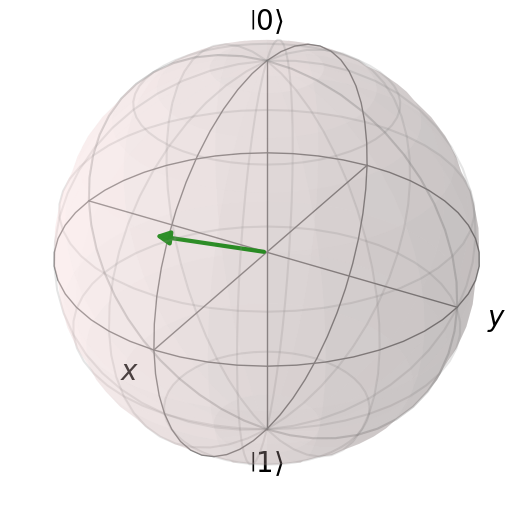

<Figure size 640x480 with 0 Axes>

In [12]:
# ex 2.5a
from qutip import Bloch, basis
import matplotlib.pyplot as plt
# definition of |0⟩ , |1⟩
e = basis(2, 0)  # حالت |0⟩⟩ (|0⟩ = [1, 0]^T)
g = basis(2, 1)  # حالت |1⟩ (|1⟩ = [0, 1]^T)

# definition wave function psi:
Psi = (1/np.sqrt(3)) * e - np.exp(3*np.pi*1j/8) * np.sqrt(2/3) * g

# normalization psi
Psi = Psi.unit()

# making bloch sphere
b = Bloch()

# adding state psi to bloch sphere
b.add_states(Psi)

# setting for optimization the bloch sphere
b.vector_color = ['g']  # vector color
b.frame_alpha = 0.2  # Frame transparency
b.point_color = ['b']  # point color

# showing bloch
b.show()

# for saving the file picture
plt.savefig("bloch_sphere.png", dpi=300)

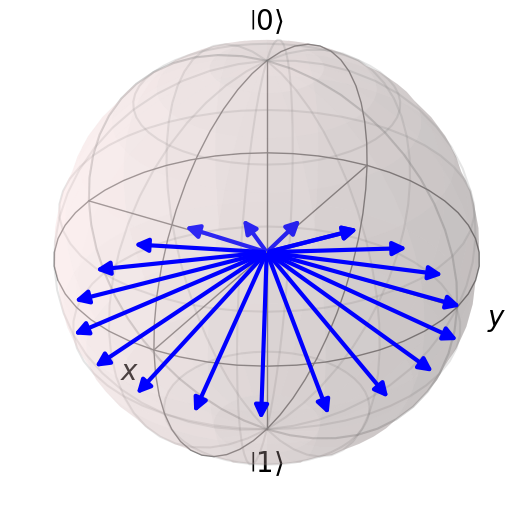

In [13]:
# ex 2.5b
# definition of |0⟩ , |1⟩
e = basis(2, 0)  # حالت |0⟩
g = basis(2, 1)  # حالت |1⟩
phi = np.linspace(0, 2 * np.pi, num=20)  # 20 نقطه بین 0 تا 2π

# making bloch sphere
b = Bloch()

# calculate psi for each value of phi 
for p in phi:
    Psi = (1/np.sqrt(3)) * e - np.exp(1j * p) * np.sqrt(2/3) * g
    b.add_states(Psi)

# setting for optimization the bloch sphere
b.vector_color = ['b'] * len(phi)  # The number of colors must be equal to the number of states
b.frame_alpha = 0.2  # Frame transparency
b.point_color = ['b']  # point color

# showing bloch
b.show()